# ThaiBMA Government Bond Yield Curve

The **Thai Bond Market Association (ThaiBMA)** publishes the official Thai government bond yield
curve — the risk-free term structure everything else in Thai finance is discounted against.

This notebook covers:

1. The latest curve, and the helpers a rates desk actually uses
2. **The silent roll-back trap** — and how settfex makes it impossible to miss
3. Percent vs basis points, the other unit trap
4. Daily history at **one request per year** (the whole 27-year record in 28 requests)
5. Plotting the term structure and its evolution
6. The per-bond matrix

Coverage runs from **1999-09-15** to the current business day.

## Setup

The ThaiBMA host is stateless — no cookies, no warm-up, no bot wall — so nothing needs configuring.

```bash
pip install settfex[dataframe]   # pandas, for the DataFrame helpers
```

In [1]:
from settfex.services.thaibma import (
    ThaiBMA,
    get_bond_yield_history,
    get_government_yield_curve,
    get_yield_curve_availability,
    get_yield_curve_history,
)
from settfex.utils.logging import setup_logger

setup_logger(level="WARNING")  # quiet the per-request info logs
tbma = ThaiBMA()

## 1. The latest curve

In [2]:
curve = await get_government_yield_curve()

print(f"as of        : {curve.as_of}")
print(f"curve points : {curve.count}")
print(f"bond quotes  : {len(curve.quotes)}")
print(f"tenors       : {', '.join(curve.tenor_labels[:10])} ...")

as of        : 2026-08-10
curve points : 53
bond quotes  : 50
tenors       : 1M, 3M, 6M, 1Y, 2Y, 3Y, 4Y, 5Y, 6Y, 7Y ...


In [3]:
# Exact grid lookups, interpolation between points, and slopes
print(f"1M  : {curve.yield_at('1M')}%")
print(f"10Y : {curve.yield_at('10Y')}%")
print(f"7.5Y (interpolated) : {curve.interpolate(7.5):.6f}%")
print()
print(f"2s10s  : {curve.slope_bps('2Y', '10Y'):+.1f} bp")
print(f"10s30s : {curve.slope_bps('10Y', '30Y'):+.1f} bp")

1M  : 0.856643%
10Y : 2.060279%
7.5Y (interpolated) : 1.855626%

2s10s  : +92.7 bp
10s30s : +108.8 bp


In [4]:
# The whole curve as a dict, in maturity order
curve.to_dict()

{'1M': 0.856643,
 '3M': 0.8717,
 '6M': 0.886454,
 '1Y': 0.945142,
 '2Y': 1.132935,
 '3Y': 1.250791,
 '4Y': 1.439915,
 '5Y': 1.564301,
 '6Y': 1.698786,
 '7Y': 1.799927,
 '8Y': 1.911325,
 '9Y': 2.004818,
 '10Y': 2.060279,
 '11Y': 2.206644,
 '12Y': 2.335298,
 '13Y': 2.431308,
 '14Y': 2.528654,
 '15Y': 2.634414,
 '16Y': 2.74464,
 '17Y': 2.870677,
 '18Y': 2.919043,
 '19Y': 2.964091,
 '20Y': 2.99072,
 '21Y': 3.022067,
 '22Y': 3.053413,
 '23Y': 3.081358,
 '24Y': 3.086833,
 '25Y': 3.092309,
 '26Y': 3.09809,
 '27Y': 3.105932,
 '28Y': 3.113775,
 '29Y': 3.123736,
 '30Y': 3.148025,
 '31Y': 3.172315,
 '32Y': 3.196604,
 '33Y': 3.220894,
 '34Y': 3.245183,
 '35Y': 3.266679,
 '36Y': 3.268311,
 '37Y': 3.269943,
 '38Y': 3.271576,
 '39Y': 3.273208,
 '40Y': 3.274653,
 '41Y': 3.274984,
 '42Y': 3.277144,
 '43Y': 3.279305,
 '44Y': 3.281466,
 '45Y': 3.283626,
 '46Y': 3.28573,
 '47Y': 3.287399,
 '48Y': 3.289069,
 '49Y': 3.290738,
 '50Y': 3.292407}

## 2. The silent roll-back — the single most important thing to know

`GET /yieldcurve/gov/{date}` **never returns a 404 for a date**. It answers with the most recent
curve *on or before* what you asked for:

| You ask for | You get |
|---|---|
| A Saturday | Friday's curve |
| A Thai public holiday | The previous business day's curve |
| **A date in 2030** | **Today's curve** |

…all with HTTP 200 and no marker in the payload. Storing the date you *requested* as the
observation date would silently corrupt your dataset.

settfex keeps both dates on every result, and the flags are **computed fields** — they survive
`model_dump()`, so a curve written to Parquet keeps the audit trail.

In [5]:
saturday = await tbma.get_yield_curve("2026-08-08")  # a Saturday

print(f"requested_date : {saturday.requested_date}")
print(f"as_of          : {saturday.as_of}")
print(f"is_rolled_back : {saturday.is_rolled_back}")
print(f"rollback_days  : {saturday.rollback_days}")
print()
print(
    "survives serialization:",
    {
        k: v
        for k, v in saturday.model_dump().items()
        if k in ("requested_date", "as_of", "is_rolled_back", "rollback_days")
    },
)

2026-08-10 20:38:04 | WARNING  | settfex.services.thaibma.yield_curve:_check_rollback:492 | ThaiBMA rolled back: requested 2026-08-08 but the curve returned is as of 2026-08-07 (1 day(s) earlier) - the requested date was a weekend or a Thai public holiday. The endpoint never 404s on a date, it serves the most recent curve on or before it.


requested_date : 2026-08-08
as_of          : 2026-08-07
is_rolled_back : True
rollback_days  : 1

survives serialization: {'requested_date': datetime.date(2026, 8, 8), 'as_of': datetime.date(2026, 8, 7), 'is_rolled_back': True, 'rollback_days': 1}


In [6]:
# A FUTURE date silently returns today's curve. rollback_days is the giveaway:
# 1-4 days = an ordinary weekend/holiday; a large number = you asked for the future.
future = await tbma.get_yield_curve("2030-01-01", on_rollback="allow")
print(f"asked for 2030-01-01, got {future.as_of} - rollback_days={future.rollback_days}")

asked for 2030-01-01, got 2026-08-10 - rollback_days=1240


### Choosing a policy

| `on_rollback` | Behaviour |
|---|---|
| `"warn"` *(default)* | Logs a warning, returns the curve, flagged |
| `"raise"` | Raises `StaleDataError` — for capture pipelines that must never write a wrong-dated row |
| `"allow"` | Silent; flags still set — for backtests that intentionally walk calendar days |

In [7]:
from settfex.exceptions import StaleDataError

try:
    await tbma.get_yield_curve("2026-08-08", on_rollback="raise")
except StaleDataError as exc:
    print(
        f"StaleDataError: requested={exc.requested_date} as_of={exc.as_of} days={exc.rollback_days}"
    )

2026-08-10 20:38:04 | ERROR    | settfex.services.thaibma.yield_curve:_check_rollback:489 | ThaiBMA rolled back: requested 2026-08-08 but the curve returned is as of 2026-08-07 (1 day(s) earlier) - the requested date was a weekend or a Thai public holiday. The endpoint never 404s on a date, it serves the most recent curve on or before it.


StaleDataError: requested=2026-08-08 as_of=2026-08-07 days=1


In [8]:
# Malformed and impossible dates are rejected BEFORE any request is made.
# ('2026-02-30' would otherwise come back HTTP 200 with the LATEST curve!)
from settfex.exceptions import InvalidDateError

for bad in ["2026-02-30", "10/08/2026", "1999-09-14"]:
    try:
        await get_government_yield_curve(bad)
    except InvalidDateError as exc:
        print(f"{bad!r:<14} -> {str(exc)[:70]}...")

2026-08-10 20:38:04 | ERROR    | settfex.services.thaibma.utils:normalize_curve_date:141 | Invalid ThaiBMA curve date '2026-02-30' - expected ISO 'YYYY-MM-DD'. Note the API answers a malformed date with an HTML 404 and an impossible one (e.g. '2026-02-30') with HTTP 200 and the LATEST curve, so this is rejected client-side.


2026-08-10 20:38:04 | ERROR    | settfex.services.thaibma.utils:normalize_curve_date:141 | Invalid ThaiBMA curve date '10/08/2026' - expected ISO 'YYYY-MM-DD'. Note the API answers a malformed date with an HTML 404 and an impossible one (e.g. '2026-02-30') with HTTP 200 and the LATEST curve, so this is rejected client-side.


2026-08-10 20:38:04 | ERROR    | settfex.services.thaibma.yield_curve:_resolve_request_date:461 | ThaiBMA has no yield curve for 1999-09-14 - the first available curve is 1999-09-15. (The API answers earlier dates with HTTP 200 and a body of literal 'null', so this is rejected client-side.)


'2026-02-30'   -> Invalid ThaiBMA curve date '2026-02-30' - expected ISO 'YYYY-MM-DD'. N...
'10/08/2026'   -> Invalid ThaiBMA curve date '10/08/2026' - expected ISO 'YYYY-MM-DD'. N...
'1999-09-14'   -> ThaiBMA has no yield curve for 1999-09-14 - the first available curve ...


## 3. Percent vs basis points

In the same row, `yield_percent` is in **percent** and `change_bps` is in **basis points**. The
field names carry the units on purpose; `change_percent` is the safe-to-add derived form.

In [9]:
quote = curve.quote("LB776A") or curve.quotes[-1]

print(f"symbol         : {quote.symbol}")
print(f"maturity       : {quote.maturity_date}")
print(f"yield_percent  : {quote.yield_percent}   <- PERCENT")
print(f"change_bps     : {quote.change_bps}      <- BASIS POINTS")
print(f"change_percent : {quote.change_percent}  <- derived, safe to add to yield_percent")
print()
print(f"yesterday's yield ~= {quote.yield_percent - quote.change_percent:.6f}%")

symbol         : LB776A
maturity       : 2077-06-17
yield_percent  : 3.293888888888889   <- PERCENT
change_bps     : -0.146033      <- BASIS POINTS
change_percent : -0.00146033  <- derived, safe to add to yield_percent

yesterday's yield ~= 3.295349%


In [10]:
# Benchmarks, T-Bills and bonds. NOTE: IsBenchmark was never backfilled before 2013,
# so this list is legitimately EMPTY for older curves - that is the data, not a bug.
print("benchmarks:", [q.symbol for q in curve.benchmarks])
print("T-Bills   :", [q.symbol for q in curve.bills])

old = await tbma.get_yield_curve("2005-01-04", on_rollback="allow")
print(
    f"\n2005 curve: {len(old.quotes)} quotes but {len(old.benchmarks)} benchmarks (flags not backfilled)"
)

benchmarks: ['LB299A', 'LB313A', 'LB365A', 'SLB406A', 'LB463A', 'LB556A', 'LB776A']
T-Bills   : ['T-BILL1M', 'T-BILL3M', 'T-BILL6M', 'T-BILL1Y']



2005 curve: 29 quotes but 0 benchmarks (flags not backfilled)


## 4. History — one request per calendar year

The obvious approach (walk business days through the point-in-time endpoint) costs ~245 requests
per year. Two bulk endpoints return **an entire year each**, so the full 1999→2026 record is
28 requests. They are not documented anywhere — only the ThaiBMA website's own JavaScript calls them.

In [11]:
availability = await get_yield_curve_availability()
print(f"coverage : {availability.first_date} .. {availability.last_date}")
print(f"span     : {availability.span_days:,} days across {len(availability.years)} years")

coverage : 1999-09-15 .. 2026-08-10
span     : 9,826 days across 28 years


In [12]:
import time

t0 = time.time()
history = await get_yield_curve_history("2020-01-01")  # 7 year-requests
print(f"{history.count} business days x {len(history.columns)} tenors in {time.time() - t0:.2f}s")
print(f"columns: {history.columns[:8]} ...")

1598 business days x 54 tenors in 1.24s
columns: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '4Y', '5Y'] ...


In [13]:
# One tenor's time series
for day, value in history.series("10Y")[-5:]:
    print(day, value)

2026-08-04 2.096629
2026-08-05 2.082052
2026-08-06 2.076031
2026-08-07 2.080184
2026-08-10 2.060279


In [14]:
df = history.to_dataframe()  # index = as_of, one column per tenor
df.tail()

,1M,3M,6M,1Y,2Y,3Y,4Y,5Y,6Y,7Y,...,42Y,43Y,44Y,45Y,46Y,47Y,48Y,49Y,50Y,51Y
as_of,,,,,,,,,,,,,,,,,,,,,
2026-08-04,0.856088,0.870456,0.886282,0.943544,1.149999,1.263176,1.453473,1.586891,1.720008,1.832733,...,3.290750,3.292388,3.294026,3.295664,3.297073,3.296397,3.295720,3.295044,3.294367,NaN
2026-08-05,0.854004,0.867287,0.884077,0.943964,1.138538,1.251980,1.442154,1.570207,1.709183,1.811570,...,3.285322,3.287417,3.289513,3.291608,3.293481,3.293383,3.293285,3.293187,3.293088,NaN
2026-08-06,0.853790,0.866720,0.883947,0.943530,1.133583,1.247139,1.440760,1.567848,1.707777,1.810521,...,3.283720,3.285518,3.287315,3.289113,3.290768,3.291201,3.291634,3.292067,3.292500,NaN
2026-08-07,0.856697,0.869545,0.885751,0.944642,1.137643,1.253609,1.444092,1.568750,1.710945,1.812002,...,3.284115,3.286046,3.287978,3.289909,3.291713,3.292455,3.293198,3.293941,3.294684,NaN
2026-08-10,0.856643,0.871700,0.886454,0.945142,1.132935,1.250791,1.439915,1.564301,1.698786,1.799927,...,3.277144,3.279305,3.281466,3.283626,3.285730,3.287399,3.289069,3.290738,3.292407,NaN


### Columns change from year to year

ThaiBMA's tenor grid grew as longer bonds were issued: **14 columns in 1999** (`1Y`…`14Y`, with no
sub-year tenors at all) up to **54 in 2026** (`1M`…`51Y`).

An **absent** column is not the same as a **null** value — `HistoryRow.has()` tells them apart,
where a wide DataFrame flattens both to `NaN`.

In [15]:
early = await get_yield_curve_history("1999-09-15", "2005-12-31")
print("columns per year:", {y: len(c) for y, c in early.columns_by_year().items()})

row_1999 = early.rows[0]
print(f"\n{row_1999.as_of}: has('1Y')={row_1999.has('1Y')}  has('1M')={row_1999.has('1M')}")
print("             -> 1999 published no sub-year tenors at all")

columns per year: {1999: 14, 2000: 14, 2001: 21, 2002: 23, 2003: 22, 2004: 21, 2005: 20}

1999-09-15: has('1Y')=True  has('1M')=False
             -> 1999 published no sub-year tenors at all


In [16]:
# The container never rolls back, unlike the endpoint: a Saturday is simply absent.
print("2026-08-07 (Fri):", history.row_for("2026-08-07") is not None)
print("2026-08-08 (Sat):", history.row_for("2026-08-08"))

2026-08-07 (Fri): True
2026-08-08 (Sat): None


## 5. Plotting the term structure

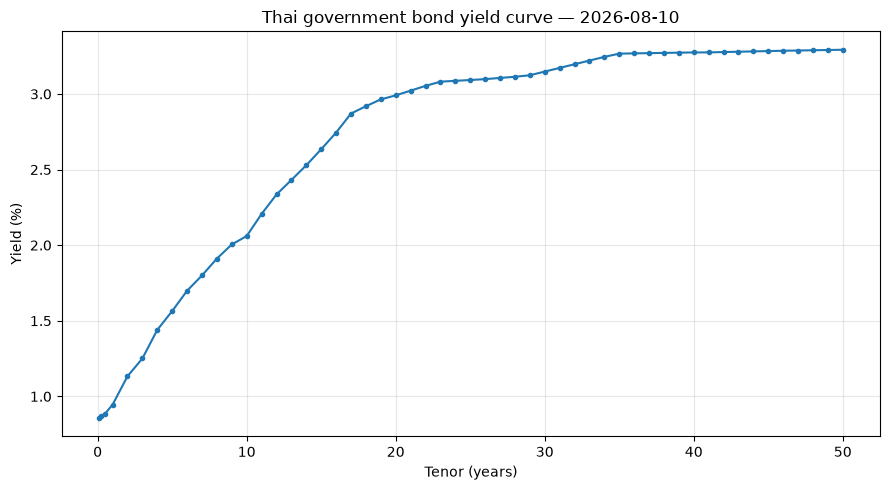

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    curve.tenors,
    [p.yield_percent for p in sorted(curve.points, key=lambda p: p.tenor_years)],
    marker="o",
    markersize=3,
)
ax.set_title(f"Thai government bond yield curve — {curve.as_of}")
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

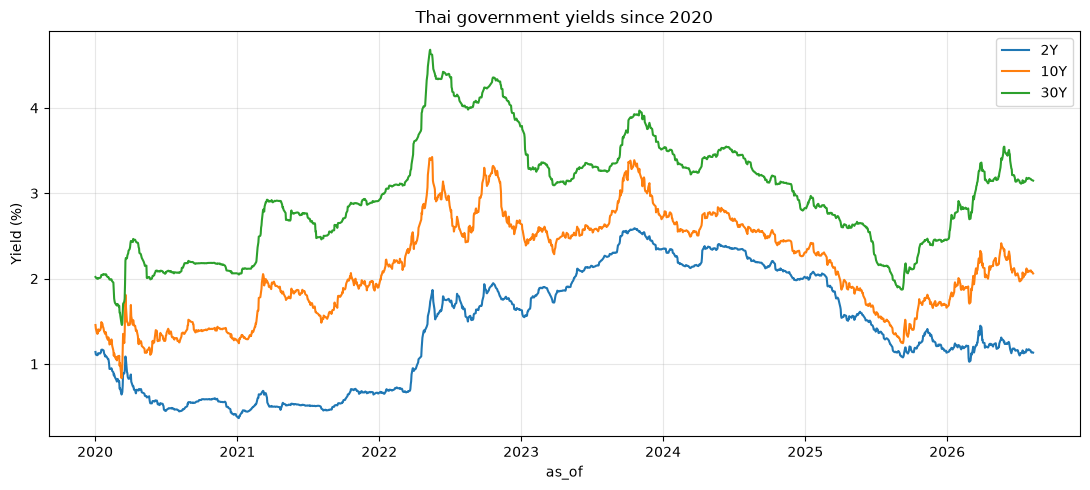

In [18]:
# How the 2Y / 10Y / 30Y have moved since 2020
fig, ax = plt.subplots(figsize=(11, 5))
for tenor in ["2Y", "10Y", "30Y"]:
    df[tenor].plot(ax=ax, label=tenor)
ax.set_title("Thai government yields since 2020")
ax.set_ylabel("Yield (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

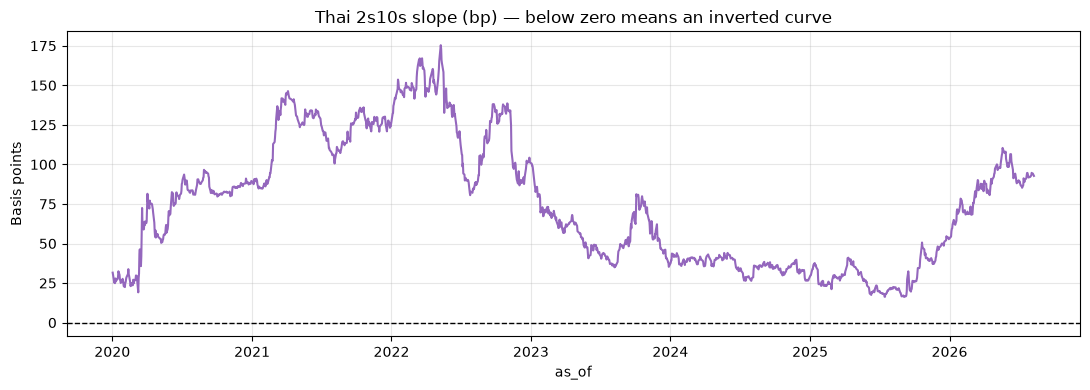

In [19]:
# The 2s10s slope - a classic recession indicator
slope = (df["10Y"] - df["2Y"]) * 100

fig, ax = plt.subplots(figsize=(11, 4))
slope.plot(ax=ax, color="tab:purple")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Thai 2s10s slope (bp) — below zero means an inverted curve")
ax.set_ylabel("Basis points")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. The per-bond matrix

`kind="bond"` returns one column per ThaiBMA bond symbol instead of per tenor. It is a **superset**
of the daily quote panel — it also carries inflation-linked (`ILB`) and amortizing (`LBA`) issues
that are quoted but excluded from curve fitting.

In [20]:
bonds = await get_bond_yield_history("2026-01-01")
print(f"{bonds.count} days x {len(bonds.columns)} bonds")
print(f"first columns: {bonds.columns[:8]}")
print()

# coverage() counts non-null observations - it spots a bond that stopped quoting
coverage = bonds.coverage()
thin = sorted(coverage.items(), key=lambda kv: kv[1])[:5]
print(f"least-quoted bonds (of {bonds.count} days): {thin}")

145 days x 59 bonds
first columns: ['T-BILL1M', 'T-BILL3M', 'T-BILL6M', 'T-BILL1Y', 'LB266A', 'LB267A', 'LB26DA', 'LB273A']

least-quoted bonds (of 145 days): [('LB299A', 12), ('LB463A', 80), ('LB266A', 108), ('LB267A', 122), ('LB365A', 133)]


In [21]:
bonds.to_dataframe()[["T-BILL1M", "LB776A"]].tail()

,T-BILL1M,LB776A
as_of,,
2026-08-04,0.856088,3.293755
2026-08-05,0.854004,3.293000
2026-08-06,0.853790,3.292889
2026-08-07,0.856697,3.295349
2026-08-10,0.856643,3.293889


## Summary

| Task | Call |
|---|---|
| Latest curve | `await get_government_yield_curve()` |
| A specific date | `await get_government_yield_curve("2026-08-10")` |
| Never accept a rolled-back date | `on_rollback="raise"` |
| Constant-maturity history | `await get_yield_curve_history(start, end)` |
| Per-bond history | `await get_bond_yield_history(start, end)` |
| What history exists | `await get_yield_curve_availability()` |

**Remember:**

- The curve endpoint never 404s on a date — always check `is_rolled_back`.
- `yield_percent` is percent; `change_bps` is basis points.
- `is_benchmark` / `is_synthetic` are all-False before 2013 / 2014.
- History is one request per **year** — never loop over days.

**👉 [Full documentation](../../docs/settfex/services/thaibma/yield_curve.md)**